In [1]:
import matplotlib.pyplot as plt
import xarray as xr
# import cmocean
from wavespectra import read_swan, read_era5
dset = read_era5("~/wavespectra/tests/sample_files/era5file.nc").isel(time=0)
ds = dset.isel(lat=3, lon=3)

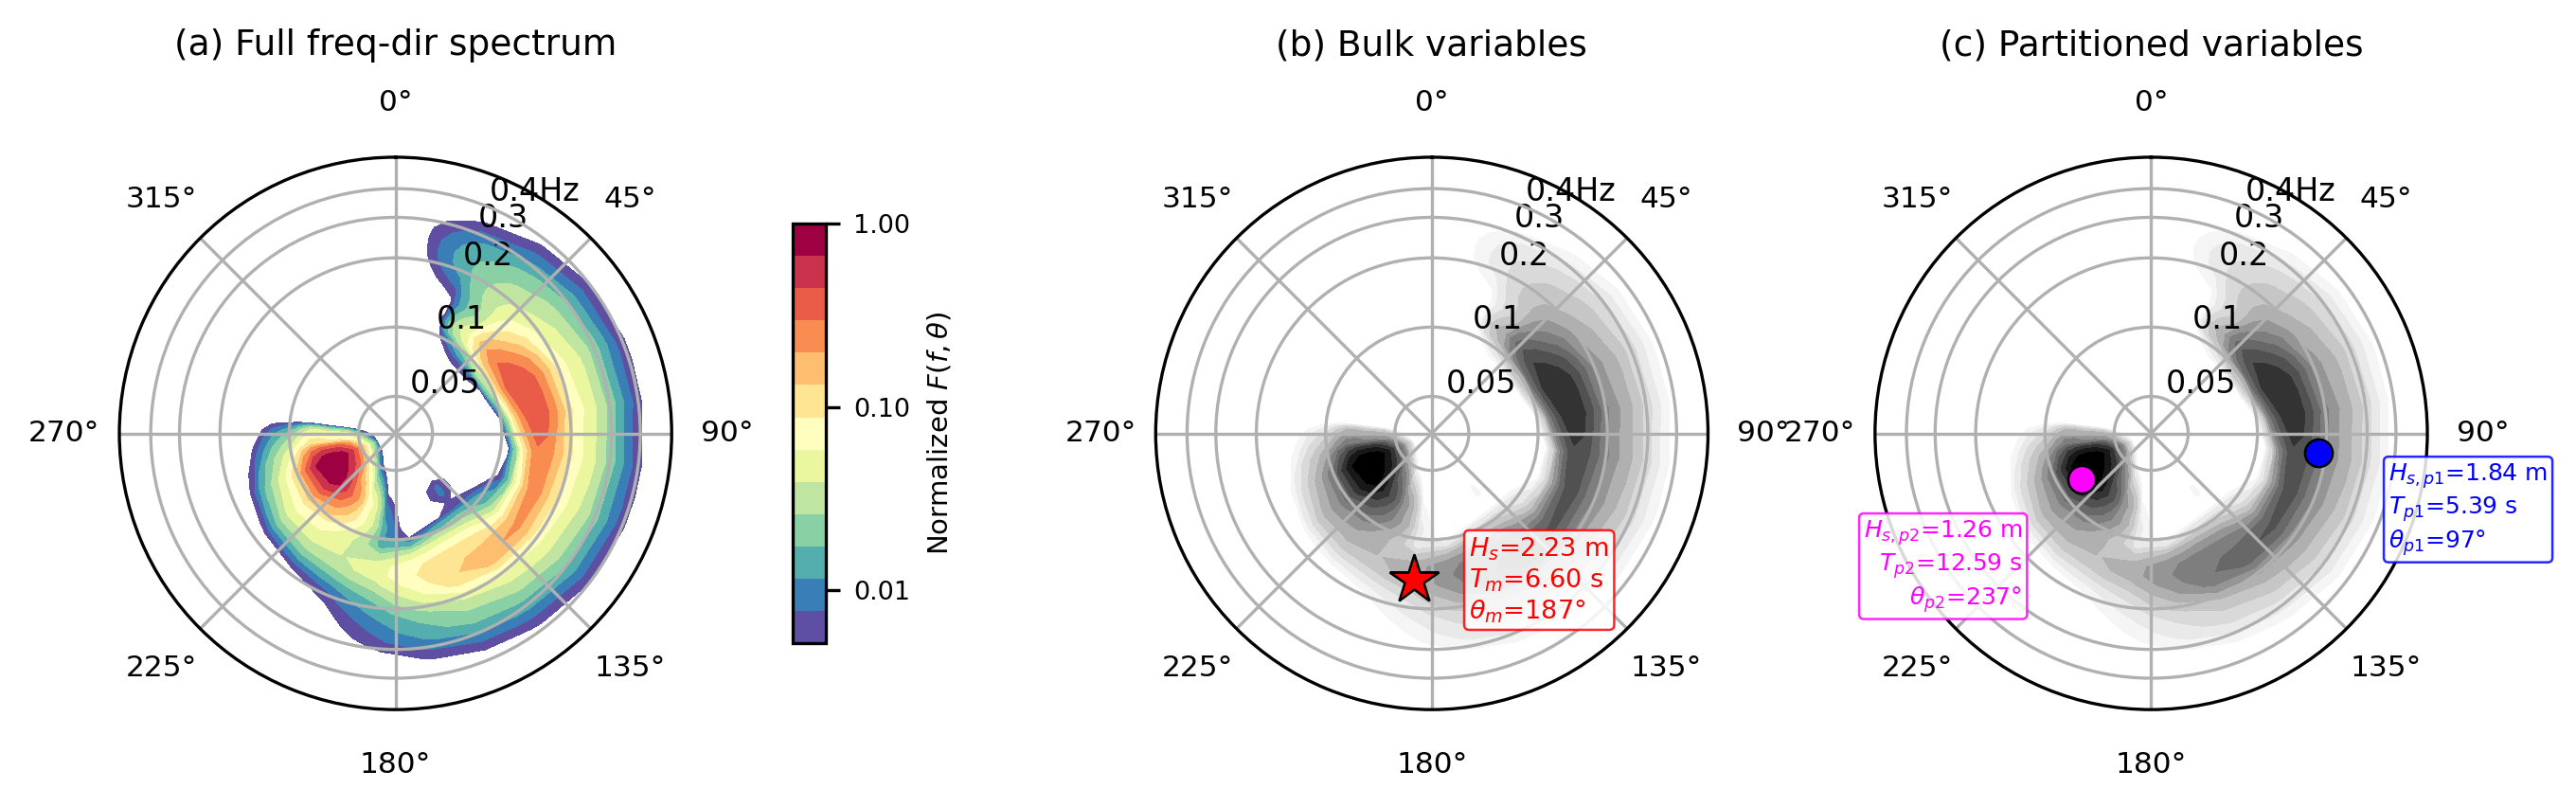

In [6]:
import numpy as np

plt.rcParams.update({
    "font.size": 7.5,
    "axes.titlesize": 9,
    "savefig.dpi": 300,
})

LOG_FACTOR = 1e3  # matches wavespectra.plot logradius transform


def r_of_freq(f):
    """Map frequency (Hz) onto the same log-radius axis used by spec.plot()."""
    return np.log10(np.asarray(f) * LOG_FACTOR)


def outward_offset(theta_deg, magnitude=18):
    """Screen-space (dx, dy) in points pointing away from the polar centre for
    a given data angle, accounting for theta_offset=90deg, theta_direction=-1,
    plus matching text alignment so the label sits on the outside of the point."""
    screen_theta = np.pi / 2 - np.deg2rad(theta_deg)
    dx, dy = np.cos(screen_theta), np.sin(screen_theta)
    ha = "left" if dx >= 0 else "right"
    va = "bottom" if dy >= 0 else "top"
    return (dx * magnitude, dy * magnitude), ha, va


# --- full-spectrum stats ---
hs = float(ds.spec.hs())
dm = float(ds.spec.dm())
fm = float(ds.spec.momf(1) / ds.spec.momf(0))
tm = 1.0 / fm  # mean period

# --- partition into 2 parts via watershed (PTM1 with zero wind disables the
# wind-sea/swell split, so it degenerates to a pure energy-based partition) ---
zeros = xr.zeros_like(ds.efth.isel(freq=0, dir=0, drop=True))
part = ds.spec.partition.ptm1(zeros, zeros, zeros + 100.0, swells=2)
part = part.isel(part=slice(1, 3))  # drop the empty wind-sea partition

hs_p = part.spec.hs().values
dm_p = part.spec.dm().values
fm_p = (part.spec.momf(1) / part.spec.momf(0)).values
tm_p = 1.0 / fm_p

order = np.argsort(-hs_p)  # partition 1 = more energetic (higher Hs)
hs_p, dm_p, fm_p, tm_p = hs_p[order], dm_p[order], fm_p[order], tm_p[order]

polar_kw = dict(projection="polar", theta_direction=-1, theta_offset=np.deg2rad(90))

# Publication-width figure. The three polar columns keep an equal 1:1:1 width
# ratio (so the spectra render at the same size); two slim non-plotting
# spacer columns control the gaps independently, giving (a)-(b) extra room for
# the colorbar (and its label) while (b)-(c) stays tight.
fig = plt.figure(figsize=(9, 2.7), dpi=300)
gs = fig.add_gridspec(1, 5, width_ratios=[1, 0.7, 1, 0.18, 1], wspace=0.0)
axes = [
    fig.add_subplot(gs[0, 0], **polar_kw),
    fig.add_subplot(gs[0, 2], **polar_kw),
    fig.add_subplot(gs[0, 4], **polar_kw),
]
fig.subplots_adjust(top=0.78, bottom=0.06, left=0.045, right=0.97)

# (a) full spectrum
plt.sca(axes[0])
pobj = ds.efth.spec.plot(add_colorbar=False, cmap="Spectral_r")
axes[0].set_title("(a) Full freq-dir spectrum", pad=26)

pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
cax = fig.add_axes([
    pos0.x1 + (pos1.x0 - pos0.x1) * 0.25,  # x: in the gap between (a) and (b)
    pos0.y0 + pos0.height * 0.12,
    0.013,
    pos0.height * 0.76,
])
cbar = fig.colorbar(pobj, cax=cax, ticks=[0, 0.01, 0.1, 1])
cbar.minorticks_off()  # contourf colorbars auto-add minor ticks at every level
cbar.ax.tick_params(labelsize=6.5)
cbar.set_label("Normalized $F(f,\\theta)$", fontsize=7)

# (b) full spectrum (grey) + mean direction/period marker (red star)
plt.sca(axes[1])
ds.efth.spec.plot(add_colorbar=False, cmap="Greys")
theta_b, r_b = np.deg2rad(dm), r_of_freq(fm)
axes[1].plot(theta_b, r_b, marker="*", color="red", markersize=13,
             markeredgecolor="k", markeredgewidth=0.6, linestyle="none", zorder=5)
axes[1].annotate(
    f"$H_s$={hs:.2f} m\n$T_m$={tm:.2f} s\n$\\theta_m$={dm:.0f}°",
    xy=(theta_b, r_b), xytext=(14, 0), textcoords="offset points",
    fontsize=6.5, color="red", ha="left", va="center",
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="red", lw=0.6, alpha=0.85),
)
axes[1].set_title("(b) Bulk variables", pad=26)

# (c) partitioned spectrum + per-partition markers (round, blue & magenta)
plt.sca(axes[2])
ds.efth.spec.plot(add_colorbar=False, cmap="Greys")
colors = ["blue", "magenta"]
psub = ["p1", "p2"]
for i in range(2):
    theta_i, r_i = np.deg2rad(dm_p[i]), r_of_freq(fm_p[i])
    axes[2].plot(theta_i, r_i, marker="o", color=colors[i], markersize=7,
                 markeredgecolor="k", markeredgewidth=0.6, linestyle="none", zorder=5)
    offset_i, ha_i, va_i = outward_offset(dm_p[i], magnitude=18)
    axes[2].annotate(
        f"$H_{{s,{psub[i]}}}$={hs_p[i]:.2f} m\n"
        f"$T_{{{psub[i]}}}$={tm_p[i]:.2f} s\n"
        f"$\\theta_{{{psub[i]}}}$={dm_p[i]:.0f}°",
        xy=(theta_i, r_i), xytext=offset_i, textcoords="offset points",
        fontsize=6, color=colors[i], ha=ha_i, va=va_i,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=colors[i], lw=0.6, alpha=0.85),
    )
axes[2].set_title("(c) Partitioned variables", pad=26)

plt.savefig("var_visual_partition.png", bbox_inches="tight")
plt.show()